Checking for dataset...
File not found. Please upload:


Saving IoTData_25K_without_interpolation_2025-05-29 10-24-09.csv to IoTData_25K_without_interpolation_2025-05-29 10-24-09 (1).csv

Loading data from CSV...

Starting Preprocessing...

Building Multi-Output CNN-LSTM Model...


/tmp/ipykernel_25867/3907588266.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_interpolated = df.interpolate(method='linear').dropna()
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Model...
Epoch 1/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0451 - mae: 0.1485 - val_loss: 0.0047 - val_mae: 0.0553
Epoch 2/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0113 - mae: 0.0835 - val_loss: 0.0027 - val_mae: 0.0421
Epoch 3/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0091 - mae: 0.0746 - val_loss: 0.0020 - val_mae: 0.0366
Epoch 4/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0078 - mae: 0.0686 - val_loss: 0.0021 - val_mae: 0.0371
Epoch 5/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0070 - mae: 0.0648 - val_loss: 0.0020 - val_mae: 0.0362
Epoch 6/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0063 - mae: 0.0612 - val_loss: 0.0017 - val_mae: 0.0329
Epoch 7/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0057 - mae: 0.0579 - val_loss: 0.0014 - val_mae: 0.0300
Epoch 8/35
639/639 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0053 - mae: 0.0554 - val_loss: 0.0015 - val_mae: 0.0323
Epoch 9/35
639/639 ━━━━━━━

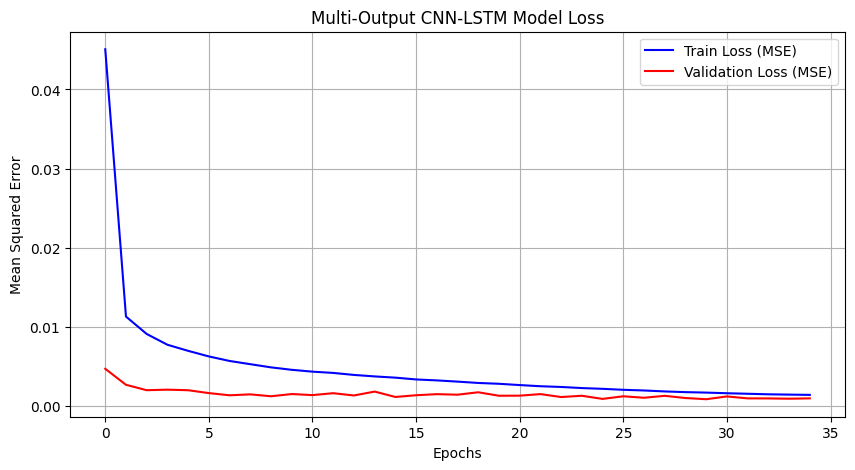

Model and scalers saved successfully!


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
import os

# ==========================================
# 1. DATA LOADING & SETUP
# ==========================================
print("Checking for dataset...")
file_name = list(uploaded.keys())[0] if 'uploaded' in locals() else 'IoTData_25K_without_interpolation.csv'

if not os.path.exists(file_name):
    print(f"File not found. Please upload:")
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]

print("\nLoading data from CSV...")
df = pd.read_csv(file_name)

# ==========================================
# 2. DATA PREPROCESSING & SCALING
# ==========================================
print("\nStarting Preprocessing...")

features = ['water_level', 'DHT_temp', 'TDS', 'pH', 'DHT_humidity']
# MULTI-OUTPUT UPDATE: The target is now ALL features, not just pH
target_cols = features

df_interpolated = df.interpolate(method='linear').dropna()

# Scale features
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler_X.fit_transform(df_interpolated[features])

# Scale targets (which is the exact same shape as features now)
scaler_y = MinMaxScaler(feature_range=(0, 1))
scaled_target = scaler_y.fit_transform(df_interpolated[target_cols])

# ==========================================
# 3. SEQUENCE GENERATION (15-STEP WINDOW)
# ==========================================
def create_sequences(data_X, data_y, time_steps):
    X, y = [], []
    for i in range(len(data_X) - time_steps):
        X.append(data_X[i:(i + time_steps)])
        y.append(data_y[i + time_steps]) # Y now contains 5 values instead of 1
    return np.array(X), np.array(y)

time_steps = 15
X_seq, y_seq = create_sequences(scaled_features, scaled_target, time_steps)

split_idx = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# ==========================================
# 4. HYBRID CNN-LSTM ARCHITECTURE
# ==========================================
print("\nBuilding Multi-Output CNN-LSTM Model...")
model = Sequential()

model.add(Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Bidirectional(LSTM(50, return_sequences=False)))
model.add(Dropout(0.4))

# MULTI-OUTPUT UPDATE: The output layer now has nodes equal to the number of features (5)
model.add(Dense(len(features), activation='linear'))

model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

# ==========================================
# 5. MODEL TRAINING
# ==========================================
print("\nTraining Model...")
history = model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================================
# 6. PARAMETER-SPECIFIC EVALUATION
# ==========================================
print("\n=============================================")
print("  MODEL PERFORMANCE BY INDIVIDUAL PARAMETER  ")
print("=============================================\n")

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Reverse the MinMax scaling to get real-world sensor values back
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)

# Define custom tolerances for what counts as an "Accurate" prediction for each specific sensor
# (e.g., being off by 10 TDS is acceptable, but being off by 10 pH is a disaster)
tolerances = {
    'water_level': 1.0,   # Accurate if within 1 liter/cm
    'DHT_temp': 0.5,      # Accurate if within 0.5 degrees
    'TDS': 20.0,          # Accurate if within 20 PPM
    'pH': 0.1,            # Accurate if within 0.1 pH
    'DHT_humidity': 2.0   # Accurate if within 2% humidity
}

# Loop through each parameter to calculate its specific error
for i, feature in enumerate(features):
    # Extract just the data for this specific feature
    actual_values = y_test_real[:, i]
    predicted_values = y_pred_real[:, i]

    # Calculate Standard Metrics
    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

    # Calculate Custom Accuracy based on the tolerance dictionary above
    tol = tolerances[feature]
    accurate_predictions = np.sum(np.abs(actual_values - predicted_values) <= tol)
    custom_accuracy = (accurate_predictions / len(actual_values)) * 100

    # Print the isolated results
    print(f"--- Sensor: {feature} ---")
    print(f"  MAE:              {mae:.4f}")
    print(f"  RMSE:             {rmse:.4f}")
    print(f"  Accuracy (±{tol}): {custom_accuracy:.2f}%\n")

# ==========================================
# 7. GRAPHING / VISUALIZATION
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('Multi-Output CNN-LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# 1. Save the neural network weights
model.save('hydroponics_ai_model.keras')

# 2. Save the scalers so you can process live data exactly like the training data
joblib.dump(scaler_X, 'scaler_features.pkl')
joblib.dump(scaler_y, 'scaler_targets.pkl')

print("Model and scalers saved successfully!")